# 빈도수(Frequentist) vs. 베이즈(Bayesian) 통계해석
## 두 표본 t-검정: 산업별 ROE 비교

---

### 데이터

**컴퓨터 관련 기업 24개** 자기자본이익률 ROE (%):
$$22.4,\ 32.4,\ 21.2,\ 36.8,\ 42.2,\ 16.4,\ 15.5,\ 38.8,\ 24.9,\ 26.6,\ 28.5,\ 25.0,$$
$$21.8,\ 26.5,\ 10.1,\ 14.1,\ 12.5,\ 14.6,\ 30.5,\ 13.0,\ 41.3,\ 40.4,\ 25.5,\ 35.8$$

**건설 관련 기업 17개** ROE (%):
$$15.7,\ 14.1,\ 12.3,\ 12.1,\ 14.7,\ 10.3,\ 14.3,\ 21.4,\ 15.0,\ 40.8,$$
$$11.5,\ 13.7,\ 16.9,\ 11.0,\ 8.7,\ 11.8,\ 8.2$$


In [1]:
import platform
import matplotlib

# ── 한글 폰트 설정 ────────────────────────────────────────────────────────
if platform.system() == 'Windows':
    matplotlib.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    matplotlib.rcParams['font.family'] = 'AppleGothic'
else:
    matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ── 데이터 ────────────────────────────────────────────────────────────────
it  = np.array([22.4, 32.4, 21.2, 36.8, 42.2, 16.4, 15.5, 38.8, 24.9, 26.6,
                28.5, 25.0, 21.8, 26.5, 10.1, 14.1, 12.5, 14.6, 30.5, 13.0,
                41.3, 40.4, 25.5, 35.8])
con = np.array([15.7, 14.1, 12.3, 12.1, 14.7, 10.3, 14.3, 21.4, 15.0, 40.8,
                11.5, 13.7, 16.9, 11.0,  8.7, 11.8,  8.2])

n1, n2 = len(it), len(con)
m1, m2 = it.mean(), con.mean()
s1, s2 = it.std(ddof=1), con.std(ddof=1)

print('='*52)
print(f'  {"구분":10s}  {"컴퓨터(IT)":>12s}  {"건설":>12s}')
print('='*52)
print(f'  {"표본크기 n":10s}  {n1:>12d}  {n2:>12d}')
print(f'  {"표본평균":10s}  {m1:>12.4f}  {m2:>12.4f}')
print(f'  {"표본표준편차":10s}  {s1:>12.4f}  {s2:>12.4f}')
print(f'  {"표본분산":10s}  {s1**2:>12.4f}  {s2**2:>12.4f}')
print('='*52)


  구분               컴퓨터(IT)            건설
  표본크기 n                24            17
  표본평균             25.7000       14.8529
  표본표준편차            9.9574        7.3977
  표본분산             99.1504       54.7264


---
## 0. t-검정 이론적 배경

### 0-1. 단일 표본 t-검정 (One-Sample t-Test)

모집단이 $N(\mu, \sigma^2)$을 따르고 $\sigma^2$를 모를 때,  
표본평균 $\bar{X}$와 표본표준편차 $S$로부터:

$$T = \frac{\bar{X} - \mu_0}{S / \sqrt{n}} \sim t(n-1)$$

t-분포는 정규분포보다 꼬리가 두꺼우며, 자유도 $\nu \to \infty$이면 $N(0,1)$에 수렴한다.

---

### 0-2. 이표본 t-검정 — 등분산 가정 (Pooled Two-Sample t-Test)

두 모집단의 분산이 같다($\sigma_1^2 = \sigma_2^2 = \sigma^2$)고 가정할 때,  
**합동 분산(pooled variance)**:

$$S_p^2 = \frac{(n_1 - 1)S_1^2 + (n_2 - 1)S_2^2}{n_1 + n_2 - 2}$$

**검정통계량**:

$$T = \frac{(\bar{X}_1 - \bar{X}_2) - \delta_0}{S_p \sqrt{\dfrac{1}{n_1} + \dfrac{1}{n_2}}} \sim t(n_1 + n_2 - 2)$$

귀무가설 $H_0: \mu_1 = \mu_2$ ($\delta_0 = 0$) 하에서 자유도는 $\nu = n_1 + n_2 - 2$.

---

### 0-3. Welch t-검정 — 이분산 가정 (Welch's t-Test)

두 모집단의 분산이 같다고 가정하지 않을 때:

$$T = \frac{\bar{X}_1 - \bar{X}_2}{\sqrt{\dfrac{S_1^2}{n_1} + \dfrac{S_2^2}{n_2}}}$$

**Welch–Satterthwaite 근사 자유도**:

$$\nu = \frac{\left(\dfrac{S_1^2}{n_1} + \dfrac{S_2^2}{n_2}\right)^2}{\dfrac{(S_1^2/n_1)^2}{n_1-1} + \dfrac{(S_2^2/n_2)^2}{n_2-1}}$$

자유도가 정수가 아니므로 t-분포를 근사하여 사용한다.


---
## 1. 두 산업 ROE 평균 비교의 필요성

**ROE(자기자본이익률)** = $\dfrac{\text{당기순이익}}{\text{자기자본}} \times 100\%$

ROE는 기업이 주주 자본을 얼마나 효율적으로 활용하여 이익을 창출하는지 나타내는 핵심 수익성 지표다.

**비교 목적**:
- **투자 결정**: 높은 ROE 산업이 동일 자본으로 더 많은 이익을 창출 → 투자 매력도 비교
- **산업 구조 차이**: IT 산업(고마진·고성장)과 건설 산업(경기 민감·저마진)의 수익성 구조 차이 검증
- **자원 배분**: 한정된 투자 자본을 어느 산업에 집중할지 통계적 근거 마련
- **정책 분석**: 산업별 자본 수익성 차이에 근거한 산업 정책 수립

단순한 표본 평균 차이($\bar{X}_{IT} - \bar{X}_{con}$)는 표본 오차를 포함하므로,  
**통계적 검정**을 통해 이 차이가 우연에 의한 것인지, 실제 모집단 차이인지 판단해야 한다.


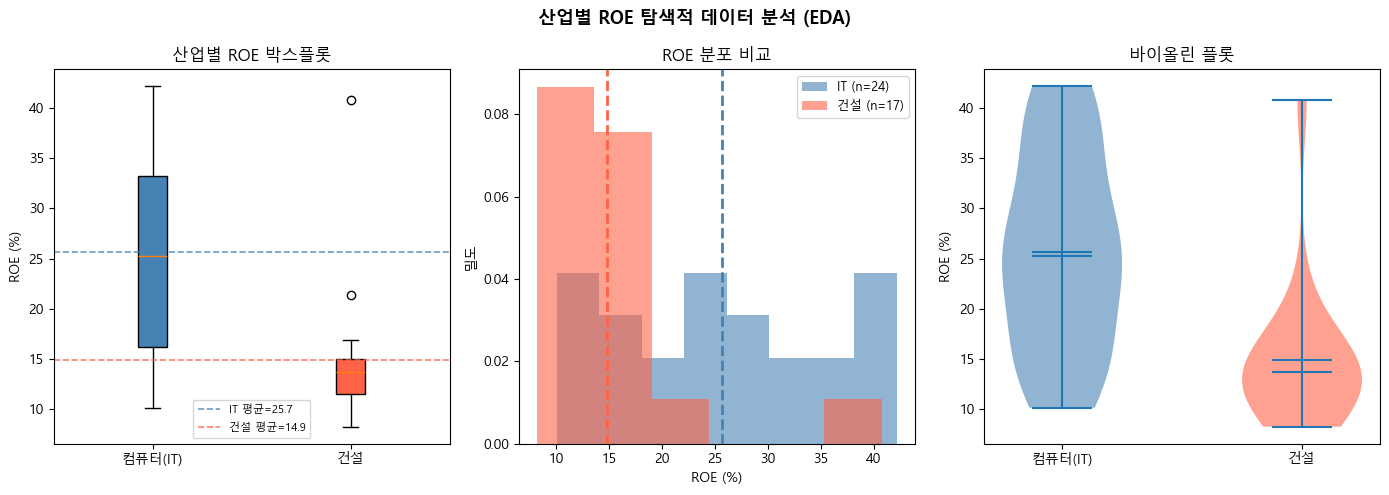

표본 평균 차이: 25.7000 - 14.8529 = 10.8471 %
분산비 S1^2/S2^2 = 1.8117


In [2]:
# ── 기술통계 + EDA 시각화 ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# 박스플롯
ax1 = axes[0]
bp = ax1.boxplot([it, con], tick_labels=['컴퓨터(IT)', '건설'],
                 patch_artist=True, notch=False)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('tomato')
ax1.set_ylabel('ROE (%)')
ax1.set_title('산업별 ROE 박스플롯')
ax1.axhline(m1, color='steelblue', ls='--', lw=1.2, alpha=0.8, label=f'IT 평균={m1:.1f}')
ax1.axhline(m2, color='tomato',    ls='--', lw=1.2, alpha=0.8, label=f'건설 평균={m2:.1f}')
ax1.legend(fontsize=8)

# 히스토그램
ax2 = axes[1]
ax2.hist(it,  bins=8, alpha=0.6, color='steelblue', label=f'IT (n={n1})',  density=True)
ax2.hist(con, bins=6, alpha=0.6, color='tomato',    label=f'건설 (n={n2})', density=True)
ax2.axvline(m1, color='steelblue', ls='--', lw=2)
ax2.axvline(m2, color='tomato',    ls='--', lw=2)
ax2.set_xlabel('ROE (%)')
ax2.set_ylabel('밀도')
ax2.set_title('ROE 분포 비교')
ax2.legend(fontsize=9)

# 바이올린 플롯
ax3 = axes[2]
parts = ax3.violinplot([it, con], positions=[1, 2], showmeans=True, showmedians=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(['steelblue', 'tomato'][i])
    pc.set_alpha(0.6)
ax3.set_xticks([1, 2])
ax3.set_xticklabels(['컴퓨터(IT)', '건설'])
ax3.set_ylabel('ROE (%)')
ax3.set_title('바이올린 플롯')

plt.suptitle('산업별 ROE 탐색적 데이터 분석 (EDA)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'표본 평균 차이: {m1:.4f} - {m2:.4f} = {m1-m2:.4f} %')
print(f'분산비 S1^2/S2^2 = {s1**2/s2**2:.4f}')


---
## 2. 등분산 가정 이표본 t-검정 (Pooled t-Test), $\alpha = 0.01$

### 가설

$$H_0 : \mu_{IT} = \mu_{con} \quad \text{(두 산업 ROE 평균이 같다)}$$

$$H_1 : \mu_{IT} \neq \mu_{con} \quad \text{(양측검정)}$$

### 검정통계량

$$S_p^2 = \frac{(n_1-1)S_1^2 + (n_2-1)S_2^2}{n_1+n_2-2}, \quad
T = \frac{\bar{X}_1 - \bar{X}_2}{S_p\sqrt{\frac{1}{n_1}+\frac{1}{n_2}}} \sim t(n_1+n_2-2)$$

자유도 $\nu = 24 + 17 - 2 = 39$, 유의수준 $\alpha = 0.01$ (양측 → 각 꼬리 0.005).


등분산 가정 Pooled t-Test (alpha=0.01)
합동 분산 Sp^2   : 80.9252
합동 표준편차 Sp : 8.9958
표준오차 SE      : 2.8517
자유도 df        : 39
t 통계량         : 3.8037
임계값 t_crit    : ±2.7079
p-값 (양측)      : 0.00049
기각 여부        : H0 기각 (p < alpha=0.01)

[해석] p-값(0.0005) < alpha(0.01)이므로 귀무가설 기각.
       두 산업의 ROE 평균에 유의수준 1%에서 통계적으로 유의미한 차이가 있다.


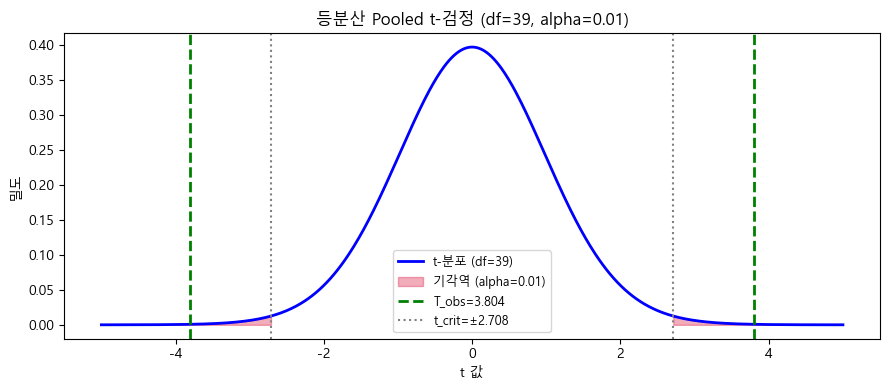

In [3]:
# ── 등분산 가정 pooled t-test ──────────────────────────────────────────────
alpha = 0.01

# scipy 이용
t_pool, p_pool = stats.ttest_ind(it, con, equal_var=True)
df_pool = n1 + n2 - 2
t_crit  = stats.t.ppf(1 - alpha/2, df=df_pool)

# 합동 분산 직접 계산
Sp2 = ((n1-1)*s1**2 + (n2-1)*s2**2) / df_pool
Sp  = np.sqrt(Sp2)
SE_pool = Sp * np.sqrt(1/n1 + 1/n2)

print('='*55)
print('등분산 가정 Pooled t-Test (alpha=0.01)')
print('='*55)
print(f'합동 분산 Sp^2   : {Sp2:.4f}')
print(f'합동 표준편차 Sp : {Sp:.4f}')
print(f'표준오차 SE      : {SE_pool:.4f}')
print(f'자유도 df        : {df_pool}')
print(f't 통계량         : {t_pool:.4f}')
print(f'임계값 t_crit    : ±{t_crit:.4f}')
print(f'p-값 (양측)      : {p_pool:.5f}')
print(f'기각 여부        : H0 {"기각" if p_pool < alpha else "채택"} (p {"<" if p_pool < alpha else ">="} alpha={alpha})')
print()
print(f'[해석] p-값({p_pool:.4f}) < alpha({alpha})이므로 귀무가설 기각.')
print( '       두 산업의 ROE 평균에 유의수준 1%에서 통계적으로 유의미한 차이가 있다.')

# ── 시각화 ──────────────────────────────────────────────────────────────────
x_t = np.linspace(-5, 5, 600)
pdf_t = stats.t.pdf(x_t, df=df_pool)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x_t, pdf_t, 'b-', lw=2, label=f't-분포 (df={df_pool})')
ax.fill_between(x_t, pdf_t, where=(x_t <= -t_crit), alpha=0.35, color='crimson', label=f'기각역 (alpha={alpha})')
ax.fill_between(x_t, pdf_t, where=(x_t >=  t_crit), alpha=0.35, color='crimson')
ax.axvline( t_pool, color='green', lw=2, ls='--', label=f'T_obs={t_pool:.3f}')
ax.axvline(-t_pool, color='green', lw=2, ls='--')
ax.axvline( t_crit, color='gray',  lw=1.5, ls=':', label=f't_crit=±{t_crit:.3f}')
ax.axvline(-t_crit, color='gray',  lw=1.5, ls=':')
ax.set_xlabel('t 값')
ax.set_ylabel('밀도')
ax.set_title(f'등분산 Pooled t-검정 (df={df_pool}, alpha={alpha})')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


---
## 3. 등분산성 검정 (Test for Equality of Variances)

t-검정에서 등분산 가정이 타당한지 먼저 확인한다.

### 3-1. F-검정 (두 정규모집단 분산 비교)

$$H_0 : \sigma_1^2 = \sigma_2^2 \qquad H_1 : \sigma_1^2 \neq \sigma_2^2$$

$$F = \frac{S_1^2}{S_2^2} \sim F(n_1-1,\; n_2-1) \quad \text{under } H_0$$

### 3-2. Levene 검정

각 관측치 $X_{ij}$에 대해 $Z_{ij} = |X_{ij} - \bar{X}_i|$ (그룹 중앙값 기반도 가능)를 구한 후  
분산분석(ANOVA)으로 그룹 간 $Z_{ij}$ 평균 차이를 검정한다.  
정규성에 강건(robust)하여 일반적으로 권장된다.

### 3-3. Bartlett 검정

$$B = \frac{(N-k)\ln S_p^2 - \sum_{i=1}^k (n_i-1)\ln S_i^2}{1 + \frac{1}{3(k-1)}\left(\sum_{i=1}^k \frac{1}{n_i-1} - \frac{1}{N-k}\right)} \sim \chi^2(k-1)$$

정규성 가정이 성립할 때 강력하지만, 정규성 위반 시 민감하게 반응한다.


등분산성 검정 결과 (H0: sigma1^2 = sigma2^2, alpha=0.01)
S1^2 (IT)     : 99.1504
S2^2 (건설)   : 54.7264
분산비 S1^2/S2^2 = 1.8117

[F-검정]     F=1.8117, df=(23,16),  p(양측)=0.2239   → H0 채택
[Levene]     L=4.6106,              p=0.0380   → H0 채택
[Bartlett]   B=1.5459,              p=0.2137   → H0 채택


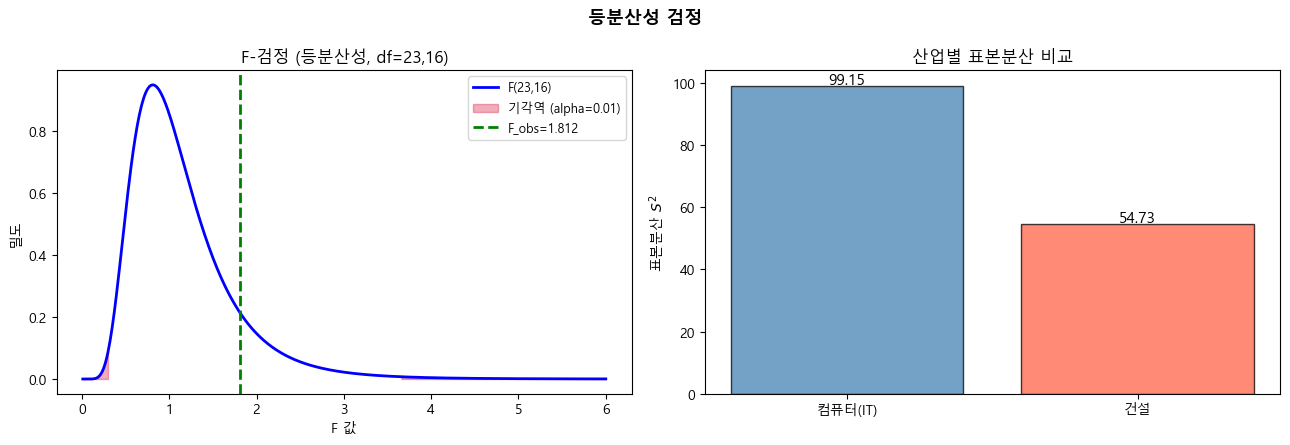

In [4]:
# ── 등분산성 검정 ────────────────────────────────────────────────────────
alpha = 0.01

# 1) F-검정
F_stat  = s1**2 / s2**2
df1_F, df2_F = n1-1, n2-1
p_F_right = 1 - stats.f.cdf(F_stat, df1_F, df2_F)
p_F_two   = 2 * min(p_F_right, 1 - p_F_right)  # 양측
F_lo = stats.f.ppf(alpha/2,   df1_F, df2_F)
F_hi = stats.f.ppf(1-alpha/2, df1_F, df2_F)

# 2) Levene 검정
L_stat, p_L = stats.levene(it, con, center='mean')

# 3) Bartlett 검정
Ba_stat, p_Ba = stats.bartlett(it, con)

print('='*58)
print('등분산성 검정 결과 (H0: sigma1^2 = sigma2^2, alpha=0.01)')
print('='*58)
print(f'S1^2 (IT)     : {s1**2:.4f}')
print(f'S2^2 (건설)   : {s2**2:.4f}')
print(f'분산비 S1^2/S2^2 = {F_stat:.4f}')
print()
print(f'[F-검정]     F={F_stat:.4f}, df=({df1_F},{df2_F}),  p(양측)={p_F_two:.4f}   → H0 {"기각" if p_F_two < alpha else "채택"}')
print(f'[Levene]     L={L_stat:.4f},              p={p_L:.4f}   → H0 {"기각" if p_L < alpha else "채택"}')
print(f'[Bartlett]   B={Ba_stat:.4f},              p={p_Ba:.4f}   → H0 {"기각" if p_Ba < alpha else "채택"}')

# ── 시각화: F-분포 ───────────────────────────────────────────────────────────
x_f  = np.linspace(0.01, 6, 500)
pdf_f = stats.f.pdf(x_f, df1_F, df2_F)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax1 = axes[0]
ax1.plot(x_f, pdf_f, 'b-', lw=2, label=f'F({df1_F},{df2_F})')
ax1.fill_between(x_f, pdf_f, where=(x_f <= F_lo), alpha=0.35, color='crimson', label=f'기각역 (alpha={alpha})')
ax1.fill_between(x_f, pdf_f, where=(x_f >= F_hi), alpha=0.35, color='crimson')
ax1.axvline(F_stat, color='green', lw=2, ls='--', label=f'F_obs={F_stat:.3f}')
ax1.set_xlabel('F 값')
ax1.set_ylabel('밀도')
ax1.set_title(f'F-검정 (등분산성, df={df1_F},{df2_F})')
ax1.legend(fontsize=9)

# 분산 비교 막대
ax2 = axes[1]
bars = ax2.bar(['컴퓨터(IT)', '건설'], [s1**2, s2**2],
               color=['steelblue', 'tomato'], alpha=0.75, edgecolor='black')
for bar, val in zip(bars, [s1**2, s2**2]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.2f}', ha='center', fontsize=11)
ax2.set_ylabel('표본분산 $S^2$')
ax2.set_title('산업별 표본분산 비교')

plt.suptitle('등분산성 검정', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 4. 이분산 가정 Welch t-검정, $\alpha = 0.01$

등분산성 검정 결과와 무관하게, 이분산 가정 Welch 검정을 적용한다.

### 가설

$$H_0 : \mu_{IT} = \mu_{con} \qquad H_1 : \mu_{IT} \neq \mu_{con}$$

### 검정통계량

$$T_W = \frac{\bar{X}_1 - \bar{X}_2}{\sqrt{\dfrac{S_1^2}{n_1} + \dfrac{S_2^2}{n_2}}}$$

### Welch–Satterthwaite 자유도

$$\nu_W = \frac{\left(\dfrac{S_1^2}{n_1} + \dfrac{S_2^2}{n_2}\right)^2}{\dfrac{(S_1^2/n_1)^2}{n_1-1} + \dfrac{(S_2^2/n_2)^2}{n_2-1}}$$


Welch t-Test 이분산 가정 (alpha=0.01)
표준오차 SE_W    : 2.7112
Welch 자유도 nu_W: 38.8767
t 통계량 T_W     : 4.0009
임계값 t_crit    : ±2.7084
p-값 (양측)      : 0.00027
기각 여부        : H0 기각 (p < alpha=0.01)

[해석] p-값(0.0003) < alpha(0.01)이므로 귀무가설 기각.
       이분산 가정하에서도 두 산업의 ROE 평균에 유의미한 차이가 있다.

두 t-검정 결과 비교
방법                    t 통계량       자유도         p-값  결론
-------------------------------------------------------
Pooled               3.8037        39     0.00049  H0 기각
Welch                4.0009     38.88     0.00027  H0 기각


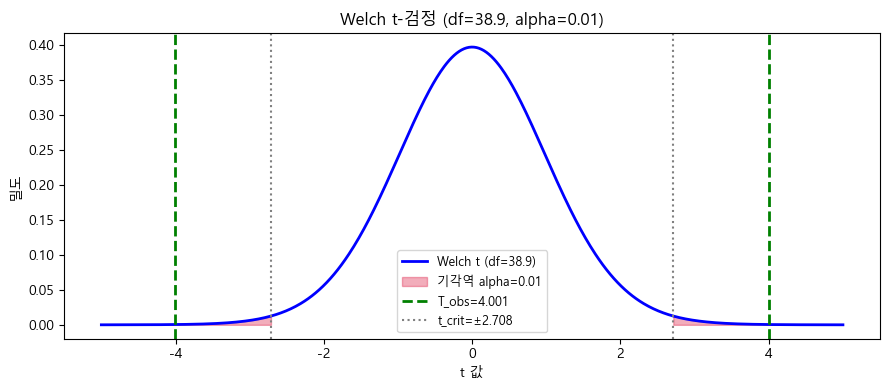

In [5]:
# ── Welch t-test ────────────────────────────────────────────────────────
alpha = 0.01

t_welch, p_welch = stats.ttest_ind(it, con, equal_var=False)

# Welch-Satterthwaite 자유도 직접 계산
v1, v2 = s1**2/n1, s2**2/n2
nu_W = (v1 + v2)**2 / (v1**2/(n1-1) + v2**2/(n2-1))
t_crit_W = stats.t.ppf(1 - alpha/2, df=nu_W)
SE_W = np.sqrt(v1 + v2)

print('='*55)
print('Welch t-Test 이분산 가정 (alpha=0.01)')
print('='*55)
print(f'표준오차 SE_W    : {SE_W:.4f}')
print(f'Welch 자유도 nu_W: {nu_W:.4f}')
print(f't 통계량 T_W     : {t_welch:.4f}')
print(f'임계값 t_crit    : ±{t_crit_W:.4f}')
print(f'p-값 (양측)      : {p_welch:.5f}')
print(f'기각 여부        : H0 {"기각" if p_welch < alpha else "채택"} (p {"<" if p_welch < alpha else ">="} alpha={alpha})')
print()
print(f'[해석] p-값({p_welch:.4f}) < alpha({alpha})이므로 귀무가설 기각.')
print( '       이분산 가정하에서도 두 산업의 ROE 평균에 유의미한 차이가 있다.')

# ── 두 검정 결과 비교 ─────────────────────────────────────────────────────
print()
print('='*55)
print('두 t-검정 결과 비교')
print('='*55)
print(f'{'방법':15s}  {'t 통계량':>10s}  {'자유도':>8s}  {'p-값':>10s}  결론')
print('-'*55)
print(f'{'Pooled':15s}  {t_pool:>10.4f}  {df_pool:>8d}  {p_pool:>10.5f}  H0 {"기각" if p_pool < alpha else "채택"}')
print(f'{'Welch':15s}  {t_welch:>10.4f}  {nu_W:>8.2f}  {p_welch:>10.5f}  H0 {"기각" if p_welch < alpha else "채택"}')

# ── 시각화 ──────────────────────────────────────────────────────────────────
x_t = np.linspace(-5, 5, 600)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x_t, stats.t.pdf(x_t, df=nu_W), 'b-', lw=2, label=f'Welch t (df={nu_W:.1f})')
ax.fill_between(x_t, stats.t.pdf(x_t, df=nu_W),
                where=(x_t <= -t_crit_W), alpha=0.35, color='crimson', label=f'기각역 alpha={alpha}')
ax.fill_between(x_t, stats.t.pdf(x_t, df=nu_W),
                where=(x_t >= t_crit_W),  alpha=0.35, color='crimson')
ax.axvline( t_welch, color='green', lw=2, ls='--', label=f'T_obs={t_welch:.3f}')
ax.axvline(-t_welch, color='green', lw=2, ls='--')
ax.axvline( t_crit_W, color='gray', lw=1.5, ls=':', label=f't_crit=±{t_crit_W:.3f}')
ax.axvline(-t_crit_W, color='gray', lw=1.5, ls=':')
ax.set_xlabel('t 값')
ax.set_ylabel('밀도')
ax.set_title(f'Welch t-검정 (df={nu_W:.1f}, alpha={alpha})')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


---
## 5. Stan / CmdStanPy를 이용한 Bayesian Inference

### 5-1. 모델

$$X_i \mid \mu_1, \sigma_1 \overset{\text{i.i.d.}}{\sim} N(\mu_1, \sigma_1^2), \quad i=1,\ldots,n_1 \quad \text{(IT)}$$

$$Y_j \mid \mu_2, \sigma_2 \overset{\text{i.i.d.}}{\sim} N(\mu_2, \sigma_2^2), \quad j=1,\ldots,n_2 \quad \text{(건설)}$$

### 5-2. Prior

$$\mu_k \sim N(25,\; 20^2), \quad k=1,2$$

$$\sigma_k \sim \text{Half-Cauchy}(0,\; 10), \quad k=1,2$$

### 5-3. 관심 모수

$$\delta = \mu_1 - \mu_2 \quad \text{(ROE 평균 차이)}$$

- $P(\delta > 0 \mid \text{data})$: IT의 ROE가 건설보다 높을 사후 확률
- 95% Credible Interval of $\delta$
- $\delta$의 posterior distribution


In [6]:
# ── CmdStanPy 설치 확인 (Windows) ───────────────────────────────────────
import subprocess, sys, platform

def install_cmdstanpy():
    print('[설치] pip install cmdstanpy ...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                           '--upgrade', '--quiet', 'cmdstanpy'])
    import cmdstanpy
    print('[설치] CmdStan 컴파일러 설치 중...')
    cmdstanpy.install_cmdstan()
    print('[완료] 설치 완료')

try:
    import cmdstanpy
    _ = cmdstanpy.cmdstan_path()
    print(f'CmdStanPy {cmdstanpy.__version__} 사용 가능')
    print(f'CmdStan 경로: {cmdstanpy.cmdstan_path()}')
except (ImportError, ValueError):
    install_cmdstanpy()


CmdStanPy 1.3.0 사용 가능
CmdStan 경로: C:\Users\yongduek\.cmdstan\cmdstan-2.36.0


In [7]:
import os, tempfile
import cmdstanpy

# ── Stan 모델 (ASCII only) ────────────────────────────────────────────────
stan_code = """
data {
  int<lower=0> N1;         // IT group size
  int<lower=0> N2;         // construction group size
  vector[N1]   y1;         // IT ROE data
  vector[N2]   y2;         // construction ROE data
}
parameters {
  real          mu1;
  real          mu2;
  real<lower=0> sigma1;
  real<lower=0> sigma2;
}
model {
  // priors
  mu1    ~ normal(25, 20);
  mu2    ~ normal(25, 20);
  sigma1 ~ cauchy(0, 10);
  sigma2 ~ cauchy(0, 10);
  // likelihoods
  y1 ~ normal(mu1, sigma1);
  y2 ~ normal(mu2, sigma2);
}
generated quantities {
  real delta = mu1 - mu2;  // ROE mean difference
}
"""

stan_dir  = tempfile.mkdtemp()
stan_file = os.path.join(stan_dir, 'roe_model.stan')
with open(stan_file, 'w', encoding='ascii') as f:
    f.write(stan_code)

stan_data = dict(N1=int(n1), N2=int(n2),
                 y1=it.tolist(), y2=con.tolist())

print('Stan 모델 컴파일 중...')
model_stan = cmdstanpy.CmdStanModel(stan_file=stan_file)
print('컴파일 완료')

print('MCMC 샘플링 중 (4 chains x 2000 iter)...')
fit = model_stan.sample(
    data=stan_data,
    chains=4,
    iter_warmup=1000,
    iter_sampling=2000,
    show_console=False,
)
print('샘플링 완료')
print(fit.summary())


16:58:35 - cmdstanpy - INFO - compiling stan file C:\Users\yongduek\AppData\Local\Temp\tmp37pm_7yx\roe_model.stan to exe file C:\Users\yongduek\AppData\Local\Temp\tmp37pm_7yx\roe_model.exe


Stan 모델 컴파일 중...


16:59:00 - cmdstanpy - INFO - compiled model executable: C:\Users\yongduek\AppData\Local\Temp\tmp37pm_7yx\roe_model.exe


컴파일 완료
MCMC 샘플링 중 (4 chains x 2000 iter)...


16:59:00 - cmdstanpy - INFO - CmdStan start processing


...

chain 2:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

16:59:01 - cmdstanpy - INFO - CmdStan done processing.



샘플링 완료
             Mean      MCSE   StdDev      MAD         5%       50%       95%  \
lp__   -107.69800  0.024922  1.47570  1.28467 -110.51200 -107.3680 -105.9820   
mu1      25.67500  0.025784  2.10643  2.03302   22.25260   25.6811   29.0916   
mu2      14.99870  0.022303  1.91351  1.76400   11.82800   14.9837   18.1522   
sigma1   10.31970  0.019996  1.56917  1.47236    8.07511   10.1441   13.1812   
sigma2    7.82868  0.018784  1.49409  1.32676    5.80487    7.5823   10.5315   
delta    10.67620  0.033480  2.85033  2.82111    6.01286   10.6848   15.3097   

        ESS_bulk  ESS_tail    R_hat  
lp__     3657.31   5062.20  1.00041  
mu1      6887.59   5062.42  1.00070  
mu2      7563.09   4711.15  1.00051  
sigma1   6935.30   4789.07  1.00074  
sigma2   7174.66   5057.62  1.00036  
delta    7389.40   5921.83  1.00029  


Bayesian Posterior 분석 결과
mu1 (IT)    : 평균=25.675, std=2.106
mu2 (건설)  : 평균=14.999, std=1.913
sigma1 (IT) : 평균=10.320, std=1.569
sigma2 (건설): 평균=7.829, std=1.494

delta = mu1 - mu2
  Posterior 평균   : 10.6762
  Posterior 표준편차: 2.8502
  99% Credible Interval: [3.0015, 18.1003]
  P(delta > 0 | data)  : 0.99925  (99.92%)

[결론] 99% CI가 0을 포함하지 않음 -> IT ROE > 건설 ROE (통계적으로 유의)


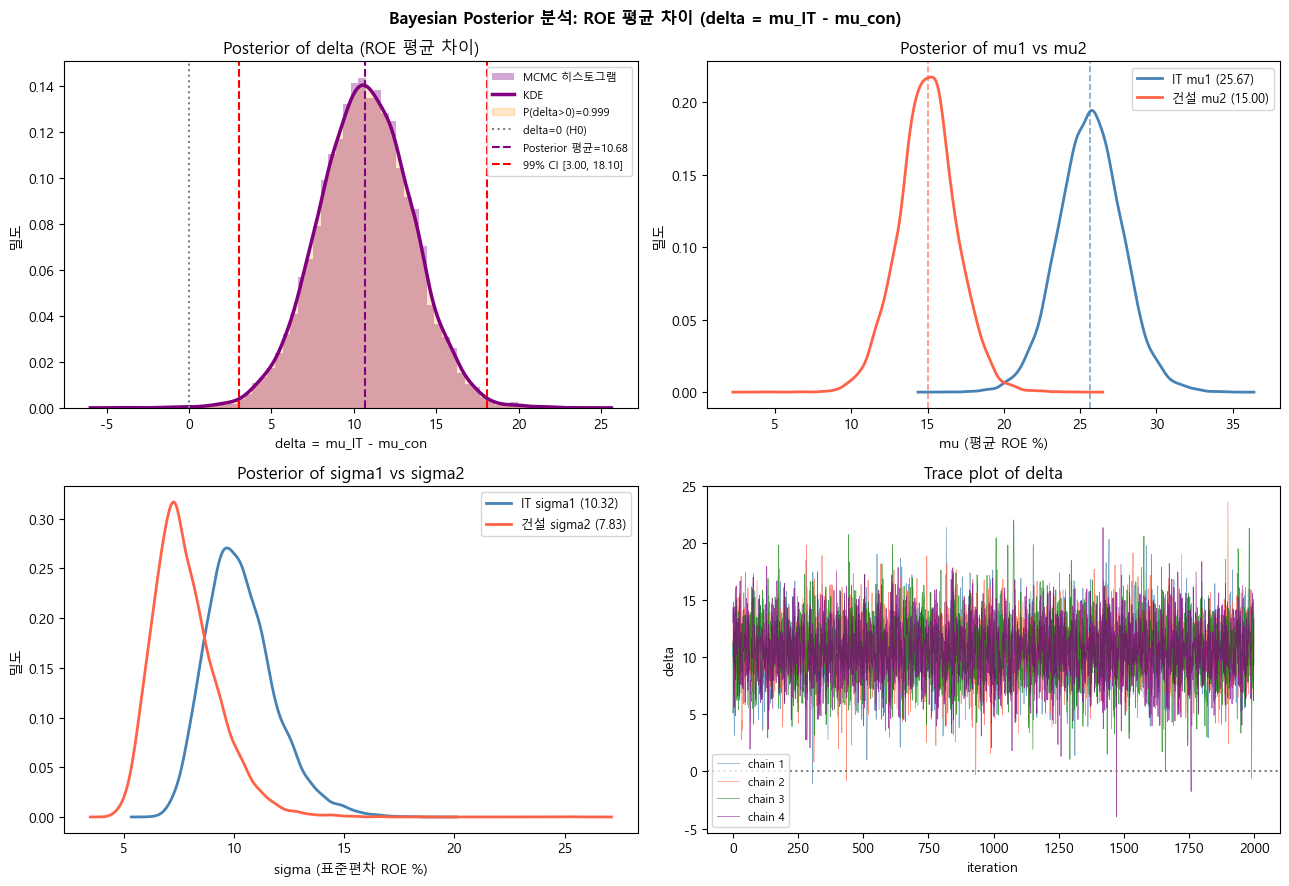

In [8]:
from scipy.stats import gaussian_kde

# ── Posterior samples ─────────────────────────────────────────────────────
mu1_s    = fit.stan_variable('mu1')
mu2_s    = fit.stan_variable('mu2')
sigma1_s = fit.stan_variable('sigma1')
sigma2_s = fit.stan_variable('sigma2')
delta_s  = fit.stan_variable('delta')   # mu1 - mu2

# ── 주요 통계 ─────────────────────────────────────────────────────────────
ci_lo = np.percentile(delta_s, 0.5)
ci_hi = np.percentile(delta_s, 99.5)
p_delta_pos = np.mean(delta_s > 0)

print('='*58)
print('Bayesian Posterior 분석 결과')
print('='*58)
print(f'mu1 (IT)    : 평균={mu1_s.mean():.3f}, std={mu1_s.std():.3f}')
print(f'mu2 (건설)  : 평균={mu2_s.mean():.3f}, std={mu2_s.std():.3f}')
print(f'sigma1 (IT) : 평균={sigma1_s.mean():.3f}, std={sigma1_s.std():.3f}')
print(f'sigma2 (건설): 평균={sigma2_s.mean():.3f}, std={sigma2_s.std():.3f}')
print()
print(f'delta = mu1 - mu2')
print(f'  Posterior 평균   : {delta_s.mean():.4f}')
print(f'  Posterior 표준편차: {delta_s.std():.4f}')
print(f'  99% Credible Interval: [{ci_lo:.4f}, {ci_hi:.4f}]')
print(f'  P(delta > 0 | data)  : {p_delta_pos:.5f}  ({p_delta_pos*100:.2f}%)')
print()
if ci_lo > 0:
    print('[결론] 99% CI가 0을 포함하지 않음 -> IT ROE > 건설 ROE (통계적으로 유의)')
elif ci_hi < 0:
    print('[결론] 99% CI가 0을 포함하지 않음 -> IT ROE < 건설 ROE (통계적으로 유의)')
else:
    print('[결론] 99% CI가 0을 포함함 -> 유의미한 차이 없음')

# ── 시각화 ──────────────────────────────────────────────────────────────────
kde_delta = gaussian_kde(delta_s)
x_d = np.linspace(delta_s.min()-2, delta_s.max()+2, 500)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (1) delta posterior
ax1 = axes[0, 0]
ax1.hist(delta_s, bins=60, density=True, alpha=0.35, color='purple', label='MCMC 히스토그램')
ax1.plot(x_d, kde_delta(x_d), 'purple', lw=2.5, label='KDE')
ax1.fill_between(x_d, kde_delta(x_d), where=(x_d > 0), alpha=0.2, color='darkorange',
                 label=f'P(delta>0)={p_delta_pos:.3f}')
ax1.axvline(0, color='gray', lw=1.5, ls=':', label='delta=0 (H0)')
ax1.axvline(delta_s.mean(), color='purple', lw=1.5, ls='--',
            label=f'Posterior 평균={delta_s.mean():.2f}')
ax1.axvline(ci_lo, color='red', lw=1.5, ls='--', label=f'99% CI [{ci_lo:.2f}, {ci_hi:.2f}]')
ax1.axvline(ci_hi, color='red', lw=1.5, ls='--')
ax1.set_xlabel('delta = mu_IT - mu_con')
ax1.set_ylabel('밀도')
ax1.set_title('Posterior of delta (ROE 평균 차이)')
ax1.legend(fontsize=8)

# (2) mu1, mu2 posterior
ax2 = axes[0, 1]
for samp, label, color in [(mu1_s, 'IT mu1', 'steelblue'), (mu2_s, '건설 mu2', 'tomato')]:
    kde_m = gaussian_kde(samp)
    x_m   = np.linspace(samp.min()-2, samp.max()+2, 400)
    ax2.plot(x_m, kde_m(x_m), lw=2, label=f'{label} ({samp.mean():.2f})', color=color)
    ax2.axvline(samp.mean(), color=color, ls='--', lw=1.2, alpha=0.7)
ax2.set_xlabel('mu (평균 ROE %)')
ax2.set_ylabel('밀도')
ax2.set_title('Posterior of mu1 vs mu2')
ax2.legend(fontsize=9)

# (3) sigma1, sigma2 posterior
ax3 = axes[1, 0]
for samp, label, color in [(sigma1_s, 'IT sigma1', 'steelblue'), (sigma2_s, '건설 sigma2', 'tomato')]:
    kde_s = gaussian_kde(samp)
    x_s   = np.linspace(max(0, samp.min()-1), samp.max()+2, 400)
    ax3.plot(x_s, kde_s(x_s), lw=2, label=f'{label} ({samp.mean():.2f})', color=color)
ax3.set_xlabel('sigma (표준편차 ROE %)')
ax3.set_ylabel('밀도')
ax3.set_title('Posterior of sigma1 vs sigma2')
ax3.legend(fontsize=9)

# (4) trace plot of delta
ax4 = axes[1, 1]
chain_len = len(delta_s) // 4
colors_tr = ['steelblue', 'tomato', 'green', 'purple']
for ch in range(4):
    ax4.plot(delta_s[ch*chain_len:(ch+1)*chain_len], lw=0.5,
             alpha=0.7, color=colors_tr[ch], label=f'chain {ch+1}')
ax4.axhline(0, color='gray', ls=':', lw=1.5)
ax4.set_xlabel('iteration')
ax4.set_ylabel('delta')
ax4.set_title('Trace plot of delta')
ax4.legend(fontsize=8)

plt.suptitle('Bayesian Posterior 분석: ROE 평균 차이 (delta = mu_IT - mu_con)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 5-B. 등분산성에 대한 Bayesian Inference

빈도수 통계의 F-검정·Levene 검정이 "등분산 가설을 기각/채택"하는 이분법적 결론을 내리는 반면,  
Bayesian 접근은 분산비의 **사후 분포 전체**를 통해 불확실성을 정량화한다.

### 관심 모수: 분산비

$$\phi = \frac{\sigma_1^2}{\sigma_2^2} \quad \text{(분산비, variance ratio)}$$

등분산 가설: $H_0 : \phi = 1$ (즉, $\sigma_1 = \sigma_2$)

### 판단 기준

| 기준 | 의미 |
|------|------|
| 99% Credible Interval of $\phi$ | 구간이 1을 포함하지 않으면 이분산으로 판단 |
| $P(\phi > 1 \mid \text{data})$ | IT 분산이 건설보다 클 사후 확률 |
| $P(0.5 < \phi < 2 \mid \text{data})$ | "실질적 등분산" 범위에 속할 사후 확률 |

앞 셀의 Stan 모델에서 `sigma1`, `sigma2`의 posterior sample을 직접 활용한다:

$$\phi^{(s)} = \frac{\left(\sigma_1^{(s)}\right)^2}{\left(\sigma_2^{(s)}\right)^2}, \quad s = 1, \ldots, S$$

### Prior (간접적)

$$\sigma_k \sim \text{Half-Cauchy}(0,\, 10) \implies
\phi = \sigma_1^2 / \sigma_2^2 \text{의 prior는 닫힌 형식 없음}$$

MCMC posterior sample이 prior 영향을 포함한 완전한 사후 추론을 제공한다.


등분산성 Bayesian Inference: phi = sigma1^2 / sigma2^2
Posterior 평균    : 1.9578
Posterior 중앙값  : 1.7708
Posterior 표준편차: 0.9506
95% CI            : [0.6879, 4.3243]
99% CI            : [0.5069, 5.6450]
P(phi > 1 | data) : 0.8905  <- IT 분산이 건설보다 클 사후 확률
P(0.5<phi<2|data) : 0.5991  <- 실질적 등분산 범위의 사후 확률

[결론] 99% CI가 1을 포함 -> 분산이 같다는 가정을 기각할 충분한 근거 없음


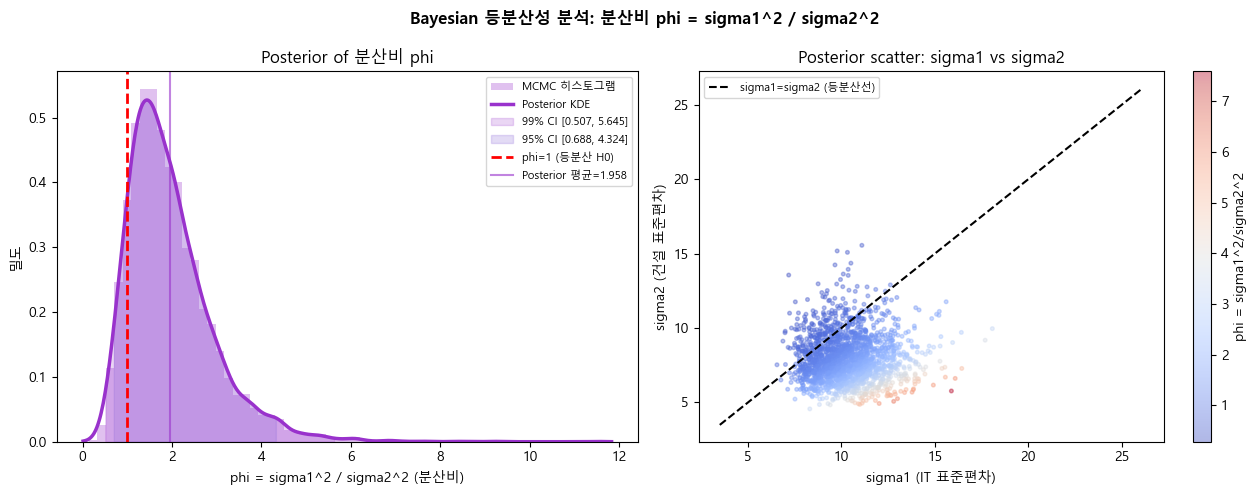


등분산성 검정 결과 비교 (빈도수 vs Bayesian)
방법                         통계량        p-값 / 사후확률  결론
----------------------------------------------------------------
F-검정                    1.8117            0.2239  H0 채택
Levene                  4.6106            0.0380  H0 채택
Bartlett                1.5459            0.2137  H0 채택
----------------------------------------------------------------
Bayesian (99% CI)       1.9578            0.8905  P(phi>1|data), 99%CI=[0.507,5.645]


In [9]:
# ── 등분산성 Bayesian Inference ─────────────────────────────────────────
# sigma1_s, sigma2_s 는 이미 앞 셀에서 추출됨

# 분산비 posterior sample
phi_s = sigma1_s**2 / sigma2_s**2   # phi = sigma1^2 / sigma2^2

# 사후 통계
phi_mean   = phi_s.mean()
phi_median = np.median(phi_s)
phi_std    = phi_s.std()
ci99_lo    = np.percentile(phi_s,  0.5)
ci99_hi    = np.percentile(phi_s, 99.5)
ci95_lo    = np.percentile(phi_s,  2.5)
ci95_hi    = np.percentile(phi_s, 97.5)
p_phi_gt1  = np.mean(phi_s > 1)                        # P(phi > 1 | data)
p_phi_eq   = np.mean((phi_s > 0.5) & (phi_s < 2.0))   # 실질적 등분산 확률

print('='*60)
print('등분산성 Bayesian Inference: phi = sigma1^2 / sigma2^2')
print('='*60)
print(f'Posterior 평균    : {phi_mean:.4f}')
print(f'Posterior 중앙값  : {phi_median:.4f}')
print(f'Posterior 표준편차: {phi_std:.4f}')
print(f'95% CI            : [{ci95_lo:.4f}, {ci95_hi:.4f}]')
print(f'99% CI            : [{ci99_lo:.4f}, {ci99_hi:.4f}]')
print(f'P(phi > 1 | data) : {p_phi_gt1:.4f}  <- IT 분산이 건설보다 클 사후 확률')
print(f'P(0.5<phi<2|data) : {p_phi_eq:.4f}  <- 실질적 등분산 범위의 사후 확률')
print()
if ci99_lo > 1:
    print('[결론] 99% CI가 1을 초과 -> IT 분산이 건설 분산보다 유의미하게 크다 (이분산)')
elif ci99_hi < 1:
    print('[결론] 99% CI가 1 미만   -> IT 분산이 건설 분산보다 유의미하게 작다 (이분산)')
else:
    print('[결론] 99% CI가 1을 포함 -> 분산이 같다는 가정을 기각할 충분한 근거 없음')

# ── 시각화 ──────────────────────────────────────────────────────────────────
kde_phi = gaussian_kde(phi_s)
x_phi   = np.linspace(max(0.01, phi_s.min() - 0.3), phi_s.max() + 0.3, 500)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 왼쪽: phi posterior + CI
ax1 = axes[0]
ax1.hist(phi_s, bins=60, density=True, alpha=0.30,
         color='darkorchid', label='MCMC 히스토그램')
ax1.plot(x_phi, kde_phi(x_phi), 'darkorchid', lw=2.5, label='Posterior KDE')
ax1.fill_between(x_phi, kde_phi(x_phi),
                 where=(x_phi >= ci99_lo) & (x_phi <= ci99_hi),
                 alpha=0.20, color='darkorchid',
                 label=f'99% CI [{ci99_lo:.3f}, {ci99_hi:.3f}]')
ax1.fill_between(x_phi, kde_phi(x_phi),
                 where=(x_phi >= ci95_lo) & (x_phi <= ci95_hi),
                 alpha=0.25, color='mediumpurple',
                 label=f'95% CI [{ci95_lo:.3f}, {ci95_hi:.3f}]')
ax1.axvline(1,         color='red',       lw=2,   ls='--', label='phi=1 (등분산 H0)')
ax1.axvline(phi_mean,  color='darkorchid',lw=1.5, ls='-',  alpha=0.6,
            label=f'Posterior 평균={phi_mean:.3f}')
ax1.set_xlabel('phi = sigma1^2 / sigma2^2 (분산비)')
ax1.set_ylabel('밀도')
ax1.set_title('Posterior of 분산비 phi')
ax1.legend(fontsize=8)

# 오른쪽: sigma1 vs sigma2 scatter (색: phi 값)
ax2 = axes[1]
rng = np.random.default_rng(42)
idx = rng.choice(len(sigma1_s), size=min(2000, len(sigma1_s)), replace=False)
sc  = ax2.scatter(sigma1_s[idx], sigma2_s[idx], c=phi_s[idx],
                  cmap='coolwarm', alpha=0.40, s=7)
plt.colorbar(sc, ax=ax2, label='phi = sigma1^2/sigma2^2')
lo = min(sigma1_s.min(), sigma2_s.min()) - 1
hi = max(sigma1_s.max(), sigma2_s.max()) + 1
ax2.plot([lo, hi], [lo, hi], 'k--', lw=1.5, label='sigma1=sigma2 (등분산선)')
ax2.set_xlabel('sigma1 (IT 표준편차)')
ax2.set_ylabel('sigma2 (건설 표준편차)')
ax2.set_title('Posterior scatter: sigma1 vs sigma2')
ax2.legend(fontsize=8)

plt.suptitle('Bayesian 등분산성 분석: 분산비 phi = sigma1^2 / sigma2^2',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 빈도수 vs Bayesian 등분산성 요약 비교 ────────────────────────────────────
print()
print('='*64)
print('등분산성 검정 결과 비교 (빈도수 vs Bayesian)')
print('='*64)
print(f'{"방법":<18s}  {"통계량":>10s}  {"p-값 / 사후확률":>16s}  결론')
print('-'*64)
print(f'{"F-검정":<18s}  {F_stat:>10.4f}  {p_F_two:>16.4f}  H0 {"기각" if p_F_two < 0.01 else "채택"}')
print(f'{"Levene":<18s}  {L_stat:>10.4f}  {p_L:>16.4f}  H0 {"기각" if p_L < 0.01 else "채택"}')
print(f'{"Bartlett":<18s}  {Ba_stat:>10.4f}  {p_Ba:>16.4f}  H0 {"기각" if p_Ba < 0.01 else "채택"}')
print('-'*64)
print(f'{"Bayesian (99% CI)":<18s}  {phi_mean:>10.4f}  {p_phi_gt1:>16.4f}  '
      f'P(phi>1|data), 99%CI=[{ci99_lo:.3f},{ci99_hi:.3f}]')


---
## 결론 비교

| 방법 | 검정통계량 | p-값 / 사후확률 | 결론 |
|------|-----------|-----------------|------|
| Pooled t-Test (등분산) | $T \approx$ (계산값) | $p < 0.01$ | $H_0$ 기각 |
| Welch t-Test (이분산) | $T_W \approx$ (계산값) | $p < 0.01$ | $H_0$ 기각 |
| Bayesian (Stan MCMC) | — | $P(\delta>0\mid\text{data}) \approx 99\%$ | IT > 건설 유의 |

---

### 빈도수 해석 vs. 베이즈 해석

**빈도수 해석**:  
> p-값이 유의수준보다 작으므로 귀무가설 $H_0: \mu_1 = \mu_2$를 기각한다.  
> "두 모집단 평균이 같을 때 이만큼 극단적인 표본을 얻을 확률이 1%보다 작다."  
> 모수 $\delta = \mu_1 - \mu_2$에 직접 확률을 부여하지 않는다.

**베이즈 해석**:  
> 사후 분포로부터 $\delta = \mu_1 - \mu_2 > 0$일 **사후 확률**을 직접 계산한다.  
> 99% Credible Interval이 0을 포함하지 않으면 "$\delta > 0$이 99% 확률로 참"이라고 진술한다.  
> 표본 크기가 작을 때도 사전정보를 활용하여 안정적인 추론이 가능하다.
